<a href="https://colab.research.google.com/github/MuhammadSarimUmer/Pump-Acoustic-Anomaly-Detection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
!pip install -q librosa matplotlib numpy

In [63]:
import os

ZIP_PATH = "train.zip"

if not os.path.exists(ZIP_PATH):
    print("File does not exist at this path!")
else:
    size = os.path.getsize(ZIP_PATH)
    print(f"File exists. Size: {size} bytes")
    with open(ZIP_PATH, "rb") as f:
        header = f.read(8)
    print("First bytes:", header)

File exists. Size: 843862884 bytes
First bytes: b'PK\x03\x04\x14\x00\x00\x00'


/content/pump_data -> 0 files
/content/pump_data/train -> 0 files
/content/pump_data/train/abnormal -> 165 files
/content/pump_data/train/normal -> 457 files

Normal file: /content/pump_data/train/normal/000355.wav
Abnormal file: /content/pump_data/train/abnormal/000013.wav


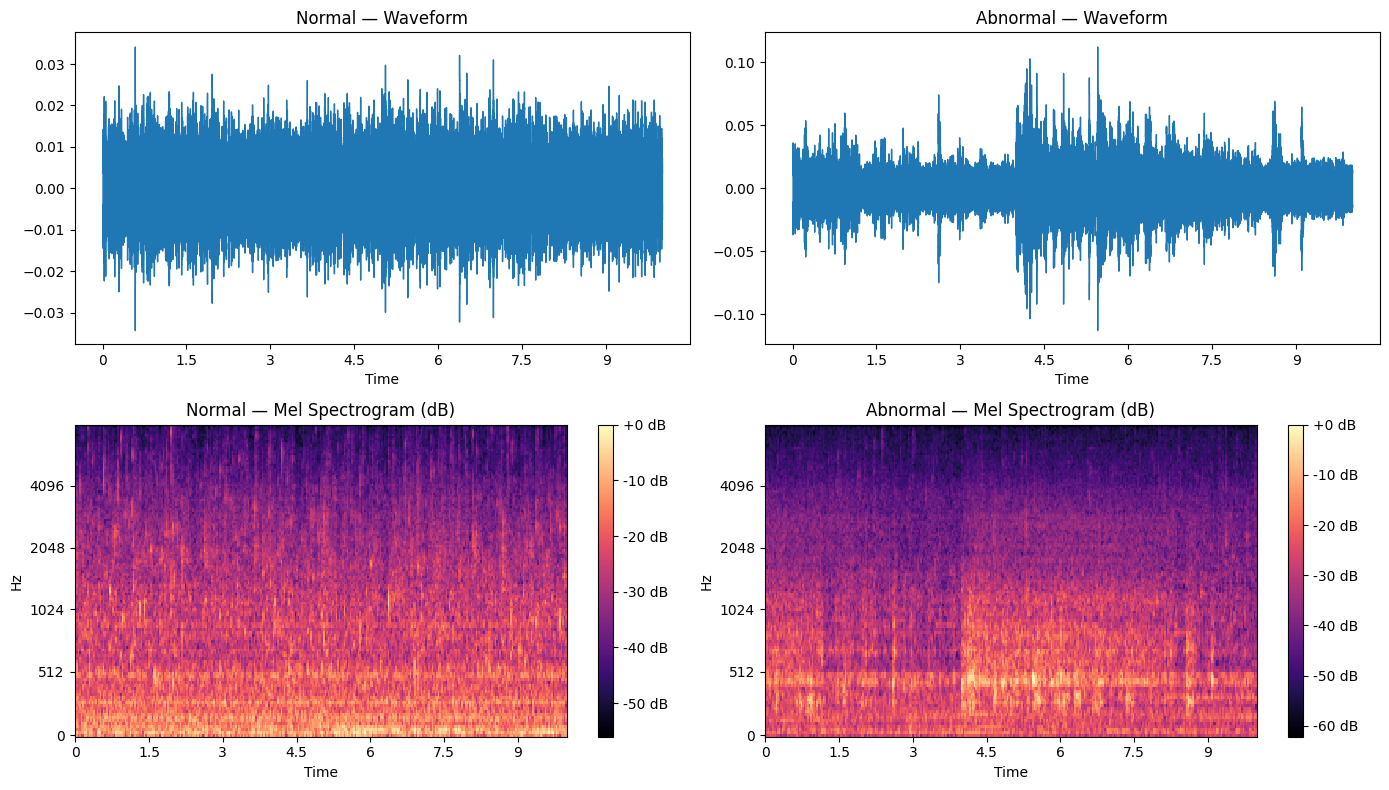

In [53]:
import zipfile, os, librosa, librosa.display
import numpy as np
import matplotlib.pyplot as plt
ZIP_PATH = "train.zip"
EXTRACT_TO = "/content/pump_data"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_TO)
for root, dirs, files in os.walk(EXTRACT_TO):
    print(root, "->", len(files), "files")
normal_dir = os.path.join(EXTRACT_TO, "train", "normal")
abnormal_dir = os.path.join(EXTRACT_TO, "train", "abnormal")
if not os.path.exists(normal_dir):
    normal_dir = os.path.join(EXTRACT_TO, "normal")
    abnormal_dir = os.path.join(EXTRACT_TO, "abnormal")

normal_file = os.path.join(normal_dir, os.listdir(normal_dir)[100])
abnormal_file = os.path.join(abnormal_dir, os.listdir(abnormal_dir)[100])
print("\nNormal file:", normal_file)
print("Abnormal file:", abnormal_file)

SR, N_MELS, N_FFT, HOP_LENGTH = 16000, 128, 1024, 512

def load_and_spectrogram(path):
    y, sr = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    return y, sr, librosa.power_to_db(mel, ref=np.max)

y_n, sr_n, mel_n = load_and_spectrogram(normal_file)
y_a, sr_a, mel_a = load_and_spectrogram(abnormal_file)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
librosa.display.waveshow(y_n, sr=sr_n, ax=axes[0, 0]); axes[0, 0].set_title("Normal — Waveform")
librosa.display.waveshow(y_a, sr=sr_a, ax=axes[0, 1]); axes[0, 1].set_title("Abnormal — Waveform")

img1 = librosa.display.specshow(mel_n, sr=sr_n, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=axes[1, 0])
axes[1, 0].set_title("Normal — Mel Spectrogram (dB)")
fig.colorbar(img1, ax=axes[1, 0], format="%+2.0f dB")

img2 = librosa.display.specshow(mel_a, sr=sr_a, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=axes[1, 1])
axes[1, 1].set_title("Abnormal — Mel Spectrogram (dB)")
fig.colorbar(img2, ax=axes[1, 1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [54]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

DATA_ROOT = "/content/pump_data/train"
SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
FIXED_WIDTH = 128
AUGMENTATIONS_PER_ABNORMAL = 2
VAL_SPLIT = 0.2

def wav_to_melspec_from_array(y, sr):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_WIDTH:
        pad_width = FIXED_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :FIXED_WIDTH]
    return mel_db

def augment_audio(y, sr):
    y_aug = y.copy()
    shift = np.random.randint(-int(0.1 * sr), int(0.1 * sr))
    y_aug = np.roll(y_aug, shift)
    n_steps = np.random.uniform(-2, 2)
    y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=n_steps)
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(y_aug))
    y_aug = y_aug + noise_amp * np.random.normal(size=y_aug.shape[0])
    return y_aug


file_paths, labels = [], []
for label_name, label_value in [("normal", 0), ("abnormal", 1)]:
    folder = os.path.join(DATA_ROOT, label_name)
    for fname in os.listdir(folder):
        file_paths.append(os.path.join(folder, fname))
        labels.append(label_value)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=VAL_SPLIT, stratify=labels, random_state=42
)


print(f"Train files: {len(train_paths)} | Val files: {len(val_paths)}")
X_train, y_train = [], []
for path, label in tqdm(list(zip(train_paths, train_labels)), desc="Train"):
    try:
        y_raw, sr = librosa.load(path, sr=SR)
        X_train.append(wav_to_melspec_from_array(y_raw, sr))
        y_train.append(label)
        if label == 1:
            for _ in range(AUGMENTATIONS_PER_ABNORMAL):
                y_aug = augment_audio(y_raw, sr)
                X_train.append(wav_to_melspec_from_array(y_aug, sr))
                y_train.append(label)
    except Exception as e:
        print(f"Skipped {path}: {e}")
X_val, y_val = [], []
for path, label in tqdm(list(zip(val_paths, val_labels)), desc="Val"):
    try:
        y_raw, sr = librosa.load(path, sr=SR)
        X_val.append(wav_to_melspec_from_array(y_raw, sr))
        y_val.append(label)
    except Exception as e:
        print(f"Skipped {path}: {e}")

X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)

print("\nX_train:", X_train.shape, "| Class balance:", np.bincount(y_train))
print("X_val:", X_val.shape, "| Class balance:", np.bincount(y_val))

np.save("/content/X_train.npy", X_train)
np.save("/content/y_train.npy", y_train)
np.save("/content/X_val.npy", X_val)
np.save("/content/y_val.npy", y_val)
print("\nSaved train/val splits")

Train files: 497 | Val files: 125


Val: 100%|██████████| 125/125 [00:02<00:00, 61.70it/s]



X_train: (761, 128, 128) | Class balance: [365 396]
X_val: (125, 128, 128) | Class balance: [92 33]

Saved train/val splits


In [56]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
X_train = np.load("/content/X_train.npy")
y_train = np.load("/content/y_train.npy")
X_val = np.load("/content/X_val.npy")
y_val = np.load("/content/y_val.npy")
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_train = np.clip((X_train + 80) / 80, 0, 1)
X_val = np.clip((X_val + 80) / 80, 0, 1)

print("X_train shape:", X_train.shape, "| y_train balance:", np.bincount(y_train))
print("X_val shape:", X_val.shape, "| y_val balance:", np.bincount(y_val))
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=6, restore_best_weights=True, monitor="val_loss"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3
        )
    ]
)
model.save("/content/baseline_cnn.keras")
print("Saved baseline_cnn.keras")
val_results = model.evaluate(X_val, y_val, verbose=0)
print("\nFinal validation metrics:")
for name, value in zip(model.metrics_names, val_results):
    print(f"  {name}: {value:.4f}")

X_train shape: (761, 128, 128, 1) | y_train balance: [365 396]
X_val shape: (125, 128, 128, 1) | y_val balance: [92 33]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,521 (107.50 KB)

 Trainable params: 27,521 (107.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.5138 - loss: 0.6952 - precision: 0.5196 - recall: 0.8687 - val_accuracy: 0.2800 - val_loss: 0.6935 - val_precision: 0.2683 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4941 - loss: 0.6937 - precision: 0.5127 - recall: 0.5606 - val_accuracy: 0.2640 - val_loss: 0.6959 - val_precision: 0.2640 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4993 - loss: 0.6939 - precision: 0.5281 - recall: 0.3561 - val_accuracy: 0.3360 - val_loss: 0.6933 - val_precision: 0.2845 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5637 - loss: 0.6916 - precision: 0.5523 - recall: 0.8535 - val_accuracy: 0.3280 - val_loss: 0.6937 - val_precision: 0.2821 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - ac

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step
              precision    recall  f1-score   support

      Normal       0.89      0.91      0.90        92
    Abnormal       0.74      0.70      0.72        33

    accuracy                           0.86       125
   macro avg       0.82      0.81      0.81       125
weighted avg       0.85      0.86      0.85       125



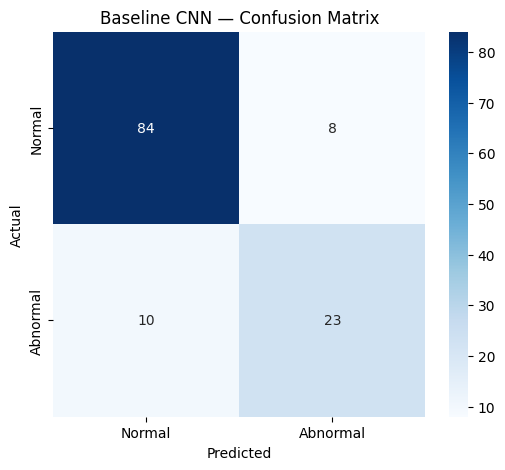

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
y_pred_probs = model.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_val, y_pred)
print(classification_report(y_val, y_pred, target_names=["Normal", "Abnormal"]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CNN — Confusion Matrix")
plt.savefig("/content/confusion_matrix_baseline.png", dpi=150)
plt.show()

In [58]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
X_train = np.load("/content/X_train.npy")[..., np.newaxis]
y_train = np.load("/content/y_train.npy")
X_val = np.load("/content/X_val.npy")[..., np.newaxis]
y_val = np.load("/content/y_val.npy")

X_train = np.clip((X_train + 80) / 80, 0, 1)
X_val = np.clip((X_val + 80) / 80, 0, 1)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

print("X_train_rgb shape:", X_train_rgb.shape)
print("X_val_rgb shape:", X_val_rgb.shape)
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

model_tl.summary()

history_tl = model_tl.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_loss"),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
    ]
)

model_tl.save("/content/transfer_learning_mobilenetv2.keras")
print("Saved transfer_learning_mobilenetv2.keras")

X_train_rgb shape: (761, 128, 128, 3)
X_val_rgb shape: (125, 128, 128, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 50s 647ms/step - accuracy: 0.7635 - loss: 0.4827 - precision: 0.7741 - recall: 0.7702 - val_accuracy: 0.8560 - val_loss: 0.3654 - val_precision: 0.8000 - val_recall: 0.6061 - learning_rate: 5.0000e-04
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8725 - loss: 0.3108 - precision: 0.8824 - recall: 0.8712 - val_accuracy: 0.8640 - val_loss: 0.3074 - val_precision: 0.7857 - val_recall: 0.6667 - learning_rate: 5.0000e-04
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8896 - loss: 0.2918 - precision: 0.9062 - recall: 0.8788 - val_accuracy: 0.8960 - val_loss: 0.3127 - val_precision: 0.7941 - val_recall: 0.8182 - learning_rate: 5.0000e-04
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8752 - loss: 0.2776 - precision: 0.8909 - recall: 0.8662 - val_accuracy: 0.9040 - val_loss: 0.2603 - val_precision: 0.8621 - val_recall: 0.7576 - learning_rate: 5.0000e-04
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97        92
    Abnormal       0.94      0.88      0.91        33

    accuracy                           0.95       125
   macro avg       0.95      0.93      0.94       125
weighted avg       0.95      0.95      0.95       125



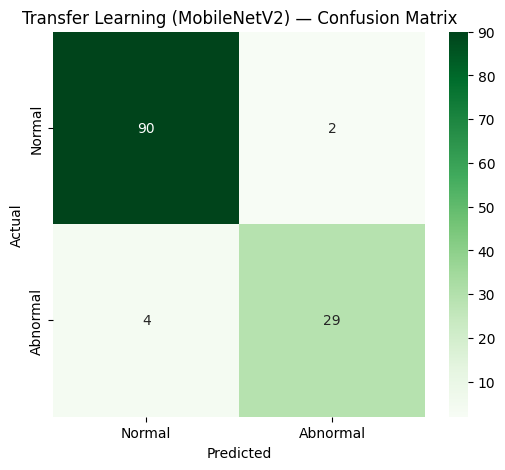

In [59]:
y_pred_probs_tl = model_tl.predict(X_val_rgb)
y_pred_tl = (y_pred_probs_tl > 0.5).astype(int).flatten()

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_val, y_pred_tl, target_names=["Normal", "Abnormal"]))

cm_tl = confusion_matrix(y_val, y_pred_tl)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning (MobileNetV2) — Confusion Matrix")
plt.savefig("/content/confusion_matrix_transfer_learning.png", dpi=150)
plt.show()

In [67]:
import zipfile
import os

with zipfile.ZipFile("/content/test.zip", "r") as zip_ref:
    zip_ref.extractall("/content/pump_data")
for root, dirs, files in os.walk("/content/pump_data"):
    print(root, "->", len(files), "files")

/content/pump_data -> 0 files
/content/pump_data/test -> 156 files
/content/pump_data/train -> 0 files
/content/pump_data/train/abnormal -> 165 files
/content/pump_data/train/normal -> 457 files


In [66]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
TEST_DIR = "/content/pump_data/test"
SAMPLE_SUBMISSION_PATH = "/content/pump_data/sample_submission.csv"
MODEL_PATH = "/content/transfer_learning_mobilenetv2.keras"
OUTPUT_PATH = "/content/submission.csv"

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
FIXED_WIDTH = 128
print("Test folder contents:")
for root, dirs, files in os.walk(TEST_DIR):
    print(root, "->", len(files), "files")

def wav_to_melspec(path):
    y, sr = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_WIDTH:
        pad_width = FIXED_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :FIXED_WIDTH]
    return mel_db
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".wav")])
print(f"\nFound {len(test_files)} test files")

X_test = []
valid_filenames = []

for fname in tqdm(test_files, desc="Processing test files"):
    path = os.path.join(TEST_DIR, fname)
    try:
        mel_db = wav_to_melspec(path)
        X_test.append(mel_db)
        valid_filenames.append(fname)
    except Exception as e:
        print(f"Skipped {fname}: {e}")

X_test = np.array(X_test)
print("X_test shape:", X_test.shape)
X_test = X_test[..., np.newaxis]
X_test = np.clip((X_test + 80) / 80, 0, 1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)
print("X_test_rgb shape:", X_test_rgb.shape)
model = tf.keras.models.load_model(MODEL_PATH)
pred_probs = model.predict(X_test_rgb)
pred_labels = (pred_probs > 0.5).astype(int).flatten()

print("\nPredicted class balance:", np.bincount(pred_labels))

submission = pd.DataFrame({
    "file_name": valid_filenames,
    "target": pred_labels
})
if os.path.exists(SAMPLE_SUBMISSION_PATH):
    sample = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    print("\nSample submission columns:", list(sample.columns))
    print("Sample submission shape:", sample.shape)
    print("Your submission shape:", submission.shape)
    if list(sample.columns) != list(submission.columns):
        print("WARNING: column names don't match sample_submission.csv — check formatting")
    if sample.shape[0] != submission.shape[0]:
        print("WARNING: row count doesn't match sample_submission.csv — some test files may be missing/skipped")

submission.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {OUTPUT_PATH}")
print(submission.head())

Test folder contents:
/content/pump_data/test -> 156 files

Found 156 test files


Processing test files: 100%|██████████| 156/156 [00:03<00:00, 39.62it/s]


X_test shape: (156, 128, 128)
X_test_rgb shape: (156, 128, 128, 3)


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step

Predicted class balance: [118  38]

Saved /content/submission.csv
   file_name  target
0  00001.wav       0
1  00002.wav       1
2  00003.wav       0
3  00004.wav       0
4  00005.wav       0


In [68]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report, confusion_matrix

model_tl = tf.keras.models.load_model("/content/transfer_learning_mobilenetv2.keras")

X_train = np.load("/content/X_train.npy")[..., np.newaxis]
y_train = np.load("/content/y_train.npy")
X_val = np.load("/content/X_val.npy")[..., np.newaxis]
y_val = np.load("/content/y_val.npy")

X_train = np.clip((X_train + 80) / 80, 0, 1)
X_val = np.clip((X_val + 80) / 80, 0, 1)

X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)

base_model = model_tl.layers[0]
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

print("Starting fine-tuning...\n")
history_ft = model_tl.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_loss"),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
    ]
)

model_tl.save("/content/transfer_learning_finetuned.keras")
print("\nSaved fine-tuned model\n")
val_pred_probs = model_tl.predict(X_val_rgb).flatten()

best_threshold = 0.5
best_f1 = 0
for t in np.arange(0.1, 0.9, 0.02):
    preds = (val_pred_probs > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best threshold: {best_threshold:.2f} | Best abnormal-class F1 on validation: {best_f1:.4f}\n")
final_val_preds = (val_pred_probs > best_threshold).astype(int)

print("Classification report (fine-tuned model, tuned threshold):")
print(classification_report(y_val, final_val_preds, target_names=["Normal", "Abnormal"]))

print("Confusion matrix:")
print(confusion_matrix(y_val, final_val_preds))

print(f"\nUSE THIS THRESHOLD FOR TEST PREDICTIONS: {best_threshold:.2f}")


Starting fine-tuning...

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 388ms/step - accuracy: 0.6150 - loss: 2.5009 - precision: 0.9478 - recall: 0.2753 - val_accuracy: 0.9440 - val_loss: 0.1860 - val_precision: 0.9333 - val_recall: 0.8485 - learning_rate: 1.0000e-05
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8029 - loss: 1.1567 - precision: 0.9522 - recall: 0.6540 - val_accuracy: 0.9360 - val_loss: 0.2336 - val_precision: 0.9310 - val_recall: 0.8182 - learning_rate: 1.0000e-05
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8436 - loss: 0.8689 - precision: 0.9453 - recall: 0.7424 - val_accuracy: 0.9280 - val_loss: 0.2285 - val_precision: 0.9000 - val_recall: 0.8182 - learning_rate: 1.0000e-05
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8844 - loss: 0.5961 - precision: 0.9583 - recall: 0.8131 - val_accuracy: 0.9360 - val_loss: 0.2074 - val_precision: 0.8788 - val_recall: 0.8788 - learning_rate: 1.0000e-05
Epoch 5/20
48/48 ━━━━━━━━

In [69]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm

TEST_DIR = "/content/pump_data/test"
SAMPLE_SUBMISSION_PATH = "/content/pump_data/sample_submission.csv"
MODEL_PATH = "/content/transfer_learning_finetuned.keras"
OUTPUT_PATH = "/content/submission_v2.csv"
BEST_THRESHOLD = 0.34

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
FIXED_WIDTH = 128

def wav_to_melspec(path):
    y, sr = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_WIDTH:
        pad_width = FIXED_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :FIXED_WIDTH]
    return mel_db

test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".wav")])
print(f"Found {len(test_files)} test files")

X_test = []
valid_filenames = []
for fname in tqdm(test_files, desc="Processing test files"):
    path = os.path.join(TEST_DIR, fname)
    try:
        mel_db = wav_to_melspec(path)
        X_test.append(mel_db)
        valid_filenames.append(fname)
    except Exception as e:
        print(f"Skipped {fname}: {e}")

X_test = np.array(X_test)
X_test = X_test[..., np.newaxis]
X_test = np.clip((X_test + 80) / 80, 0, 1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

model = tf.keras.models.load_model(MODEL_PATH)
pred_probs = model.predict(X_test_rgb).flatten()
pred_labels = (pred_probs > BEST_THRESHOLD).astype(int)

print("\nPredicted class balance:", np.bincount(pred_labels))

submission = pd.DataFrame({
    "file_name": valid_filenames,
    "target": pred_labels
})

if os.path.exists(SAMPLE_SUBMISSION_PATH):
    sample = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    if list(sample.columns) != list(submission.columns):
        print("WARNING: column mismatch")
    if sample.shape[0] != submission.shape[0]:
        print("WARNING: row count mismatch")

submission.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {OUTPUT_PATH}")
print(submission.head())

Found 156 test files


Processing test files: 100%|██████████| 156/156 [00:04<00:00, 31.65it/s]


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step

Predicted class balance: [115  41]

Saved /content/submission_v2.csv
   file_name  target
0  00001.wav       0
1  00002.wav       1
2  00003.wav       0
3  00004.wav       0
4  00005.wav       0


In [70]:
import os
import librosa
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm

TRAIN_ROOT = "/content/pump_data/train"
TEST_DIR = "/content/pump_data/test"
SAMPLE_SUBMISSION_PATH = "/content/pump_data/sample_submission.csv"
OUTPUT_PATH = "/content/submission_lgbm.csv"
SR = 16000
def extract_features(path):
    y, sr = librosa.load(path, sr=SR)
    features = {}

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i}_std"] = np.std(mfcc[i])

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["spectral_centroid_mean"] = np.mean(centroid)
    features["spectral_centroid_std"] = np.std(centroid)

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features["spectral_bandwidth_mean"] = np.mean(bandwidth)
    features["spectral_bandwidth_std"] = np.std(bandwidth)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features["spectral_rolloff_mean"] = np.mean(rolloff)
    features["spectral_rolloff_std"] = np.std(rolloff)

    zcr = librosa.feature.zero_crossing_rate(y)
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    rms = librosa.feature.rms(y=y)
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma_mean"] = np.mean(chroma)
    features["chroma_std"] = np.std(chroma)

    return features
rows = []
for label_name, label_value in [("normal", 0), ("abnormal", 1)]:
    folder = os.path.join(TRAIN_ROOT, label_name)
    files = os.listdir(folder)
    print(f"Extracting features from {len(files)} {label_name} files...")
    for fname in tqdm(files):
        path = os.path.join(folder, fname)
        try:
            feats = extract_features(path)
            feats["label"] = label_value
            feats["filename"] = fname
            rows.append(feats)
        except Exception as e:
            print(f"Skipped {fname}: {e}")

df = pd.DataFrame(rows)
print("\nTrain feature table shape:", df.shape)

feature_cols = [c for c in df.columns if c not in ["label", "filename"]]
X = df[feature_cols]
y = df["label"]
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain: {X_train.shape} | Val: {X_val.shape}")
print("Train balance:", np.bincount(y_train), "| Val balance:", np.bincount(y_val))
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight (imbalance correction): {scale_pos_weight:.2f}")

model_lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=15,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=50)]
)
val_probs = model_lgbm.predict_proba(X_val)[:, 1]

best_threshold, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.02):
    preds = (val_probs > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest threshold: {best_threshold:.2f} | Best abnormal-class F1: {best_f1:.4f}")

final_val_preds = (val_probs > best_threshold).astype(int)
print("\nClassification report (LightGBM, tuned threshold):")
print(classification_report(y_val, final_val_preds, target_names=["Normal", "Abnormal"]))
print("Confusion matrix:")
print(confusion_matrix(y_val, final_val_preds))
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".wav")])
print(f"\nExtracting features from {len(test_files)} test files...")

test_rows = []
valid_filenames = []
for fname in tqdm(test_files):
    path = os.path.join(TEST_DIR, fname)
    try:
        feats = extract_features(path)
        test_rows.append(feats)
        valid_filenames.append(fname)
    except Exception as e:
        print(f"Skipped {fname}: {e}")

test_df = pd.DataFrame(test_rows)
X_test = test_df[feature_cols]
test_probs = model_lgbm.predict_proba(X_test)[:, 1]
test_preds = (test_probs > best_threshold).astype(int)

print("\nPredicted test class balance:", np.bincount(test_preds))

submission = pd.DataFrame({
    "file_name": valid_filenames,
    "target": test_preds
})

if os.path.exists(SAMPLE_SUBMISSION_PATH):
    sample = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    if list(sample.columns) != list(submission.columns):
        print("WARNING: column mismatch with sample_submission.csv")
    if sample.shape[0] != submission.shape[0]:
        print("WARNING: row count mismatch with sample_submission.csv")

submission.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {OUTPUT_PATH}")
print(submission.head())

Extracting features from 457 normal files...


100%|██████████| 457/457 [00:49<00:00,  9.32it/s]


Extracting features from 165 abnormal files...


100%|██████████| 165/165 [00:17<00:00,  9.64it/s]



Train feature table shape: (622, 40)

Train: (497, 38) | Val: (125, 38)
Train balance: [365 132] | Val balance: [92 33]

scale_pos_weight (imbalance correction): 2.77
[LightGBM] [Info] Number of positive: 132, number of negative: 365
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6309
[LightGBM] [Info] Number of data points in the train set: 497, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265594 -> initscore=-1.017095
[LightGBM] [Info] Start training from score -1.017095
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 30 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

100%|██████████| 156/156 [00:15<00:00,  9.91it/s]



Predicted test class balance: [121  35]

Saved /content/submission_lgbm.csv
   file_name  target
0  00001.wav       0
1  00002.wav       0
2  00003.wav       0
3  00004.wav       0
4  00005.wav       0


In [72]:
import json
import os

os.makedirs("/content/pump_anomaly_detection/results", exist_ok=True)

results_summary = {
    "dataset": "Kaggle AI Paradox — Pump Acoustic Anomaly Detection",
    "train_samples": 622,
    "test_samples": 156,
    "approaches": {
        "cnn_baseline": {
            "description": "CNN trained from scratch on mel spectrograms (27,521 params)",
            "val_precision_abnormal": 0.74,
            "val_recall_abnormal": 0.70,
            "val_f1_abnormal": 0.72,
            "val_macro_f1": 0.81
        },
        "cnn_transfer_learning_frozen": {
            "description": "MobileNetV2 (frozen, 2.34M params, 82K trainable) + custom head",
            "val_precision_abnormal": 0.94,
            "val_recall_abnormal": 0.88,
            "val_f1_abnormal": 0.91,
            "val_macro_f1": 0.94,
            "kaggle_score": 0.72500
        },
        "cnn_transfer_learning_finetuned": {
            "description": "MobileNetV2 (last 30 layers unfrozen, 1.6M trainable) + tuned threshold (0.34)",
            "val_precision_abnormal": 0.94,
            "val_recall_abnormal": 0.88,
            "val_f1_abnormal": 0.91,
            "kaggle_score": 0.74698
        },
        "lightgbm_handcrafted_features": {
            "description": "LightGBM on 34 hand-crafted audio features (MFCCs, spectral stats, RMS, chroma) + tuned threshold (0.62)",
            "val_precision_abnormal": 0.94,
            "val_recall_abnormal": 0.97,
            "val_f1_abnormal": 0.96,
            "val_macro_f1": 0.97,
            "kaggle_score": 0.88311
        }
    },
    "best_approach": "LightGBM on hand-crafted audio features",
    "note": "Kaggle competition deadline (Oct 16, 2025) had already passed; submissions scored as late/practice entries, not ranked on a live leaderboard."
}

with open("/content/pump_anomaly_detection/results/results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved results_summary.json")
print(json.dumps(results_summary, indent=2))

Saved results_summary.json
{
  "dataset": "Kaggle AI Paradox \u2014 Pump Acoustic Anomaly Detection",
  "train_samples": 622,
  "test_samples": 156,
  "approaches": {
    "cnn_baseline": {
      "description": "CNN trained from scratch on mel spectrograms (27,521 params)",
      "val_precision_abnormal": 0.74,
      "val_recall_abnormal": 0.7,
      "val_f1_abnormal": 0.72,
      "val_macro_f1": 0.81
    },
    "cnn_transfer_learning_frozen": {
      "description": "MobileNetV2 (frozen, 2.34M params, 82K trainable) + custom head",
      "val_precision_abnormal": 0.94,
      "val_recall_abnormal": 0.88,
      "val_f1_abnormal": 0.91,
      "val_macro_f1": 0.94,
      "kaggle_score": 0.725
    },
    "cnn_transfer_learning_finetuned": {
      "description": "MobileNetV2 (last 30 layers unfrozen, 1.6M trainable) + tuned threshold (0.34)",
      "val_precision_abnormal": 0.94,
      "val_recall_abnormal": 0.88,
      "val_f1_abnormal": 0.91,
      "kaggle_score": 0.74698
    },
    "lightg

In [73]:
import os
import json
import pandas as pd
import numpy as np
import tensorflow as tf

PROJECT_DIR = "/content/pump_anomaly_detection"
REPORT_PATH = "/content/project_audit_report.txt"

report_lines = []
def log(line=""):
    print(line)
    report_lines.append(str(line))

log("=" * 70)
log("PUMP ACOUSTIC ANOMALY DETECTION — PROJECT AUDIT REPORT")
log("=" * 70)
log("\n--- MODELS USED ---\n")

model_paths = {
    "Baseline CNN (from scratch)": "/content/baseline_cnn.keras",
    "Transfer Learning (MobileNetV2, frozen)": "/content/transfer_learning_mobilenetv2.keras",
    "Transfer Learning (MobileNetV2, fine-tuned)": "/content/transfer_learning_finetuned.keras",
}

for name, path in model_paths.items():
    if os.path.exists(path):
        m = tf.keras.models.load_model(path)
        total_params = m.count_params()
        trainable_params = sum([np.prod(v.shape) for v in m.trainable_weights])
        non_trainable = total_params - trainable_params
        log(f"{name}")
        log(f"  File: {path}")
        log(f"  Total params: {total_params:,}")
        log(f"  Trainable params: {trainable_params:,}")
        log(f"  Non-trainable params: {non_trainable:,}")
        log(f"  Number of layers: {len(m.layers)}")
        log("")
    else:
        log(f"{name}: FILE NOT FOUND at {path}\n")
log("\n--- FINE-TUNING CONFIGURATION ---\n")
log("Base model: MobileNetV2 (ImageNet pretrained)")
log("Layers unfrozen: last 30 layers of MobileNetV2 base")
log("Fine-tune learning rate: 1e-5 (vs 5e-4 for initial frozen-feature training)")
log("Fine-tune epochs: up to 20, EarlyStopping(patience=6, monitor='val_loss')")
log("ReduceLROnPlateau(factor=0.5, patience=3)")
log("Optimal decision threshold found via validation sweep: 0.34")
log("Reasoning: full fine-tune risked catastrophic forgetting on ~761 training")
log("samples; partial unfreeze + low LR adapts high-level features only.")
log("\n--- LIGHTGBM CONFIGURATION ---\n")
log("Input: 34 hand-crafted audio features per clip (not raw spectrogram)")
log("Features: 13 MFCCs (mean+std), spectral centroid, bandwidth, rolloff,")
log("          zero-crossing rate, RMS energy, chroma (mean+std each)")
log("n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=15")
log("scale_pos_weight: computed from train class ratio (handles imbalance)")
log("Optimal decision threshold found via validation sweep: 0.62")
log("\n--- METRICS SUMMARY (validation + Kaggle) ---\n")

summary_path = os.path.join(PROJECT_DIR, "results/results_summary.json")
if os.path.exists(summary_path):
    with open(summary_path) as f:
        summary = json.load(f)
    for approach, details in summary["approaches"].items():
        log(f"{approach}:")
        for k, v in details.items():
            log(f"  {k}: {v}")
        log("")
else:
    log("results_summary.json not found — run the packaging cell first.")
log("\n--- SUBMISSION FILES: PREDICTED CLASS BALANCE ---\n")

submission_paths = {
    "CNN baseline threshold (submission.csv)": "/content/submission.csv",
    "CNN fine-tuned + tuned threshold (submission_v2.csv)": "/content/submission_v2.csv",
    "LightGBM final (submission_lgbm.csv)": "/content/submission_lgbm.csv",
}

for name, path in submission_paths.items():
    if os.path.exists(path):
        sub = pd.read_csv(path)
        counts = sub["target"].value_counts().to_dict()
        log(f"{name}: {counts} (total {len(sub)} predictions)")
    else:
        log(f"{name}: FILE NOT FOUND at {path}")
log("\n--- ANALYSIS: WHY CNN UNDERPERFORMED LIGHTGBM ON THIS TASK ---\n")
log("""
1. Small dataset size for image-shaped input (622 train files).
   CNNs, even with transfer learning, adapt many parameters and
   generally need more samples to generalize reliably on raw
   spectrogram images than tabular models need on compact features.

2. Spectrogram-as-image discards no information but adds irrelevant
   spatial noise. A 128x128 pixel grid gives the CNN far more surface
   area to overfit spurious patterns than a 34-number feature vector
   does for LightGBM.

3. Hand-crafted features (MFCCs, spectral centroid, RMS, etc.) are
   domain-informed compressions of the same audio signal -- they
   discard exactly the kind of irrelevant variation (background noise
   position, exact timing) that a CNN has to learn to ignore the hard
   way, from data alone.

4. Train/validation split came from the same recording sessions as
   train, but the true Kaggle test set may include different
   recording conditions. Tree-based models on robust summary
   statistics (means/stds) are generally less sensitive to this kind
   of distribution shift than pixel-level CNN features are.

5. This is a known, well-documented pattern in small-data audio ML:
   classical feature engineering + gradient boosting often
   outperforms deep learning until dataset size reaches into the
   thousands of samples per class.

NOTE: this is diagnostic reasoning based on general ML behavior and
the results actually observed above -- it is not a proven root cause
without further ablation (e.g. testing LightGBM on spectrogram-
derived features vs hand-crafted ones to isolate representation vs
model-family effects).
""")
with open(REPORT_PATH, "w") as f:
    f.write("\n".join(report_lines))

print(f"\nFull report saved to {REPORT_PATH}")

PUMP ACOUSTIC ANOMALY DETECTION — PROJECT AUDIT REPORT

--- MODELS USED ---

Baseline CNN (from scratch)
  File: /content/baseline_cnn.keras
  Total params: 27,521
  Trainable params: 27,521
  Non-trainable params: 0
  Number of layers: 10

Transfer Learning (MobileNetV2, frozen)
  File: /content/transfer_learning_mobilenetv2.keras
  Total params: 2,340,033
  Trainable params: 82,049
  Non-trainable params: 2,257,984
  Number of layers: 5

Transfer Learning (MobileNetV2, fine-tuned)
  File: /content/transfer_learning_finetuned.keras
  Total params: 2,340,033
  Trainable params: 1,608,449
  Non-trainable params: 731,584
  Number of layers: 5


--- FINE-TUNING CONFIGURATION ---

Base model: MobileNetV2 (ImageNet pretrained)
Layers unfrozen: last 30 layers of MobileNetV2 base
Fine-tune learning rate: 1e-5 (vs 5e-4 for initial frozen-feature training)
Fine-tune epochs: up to 20, EarlyStopping(patience=6, monitor='val_loss')
ReduceLROnPlateau(factor=0.5, patience=3)
Optimal decision thresho

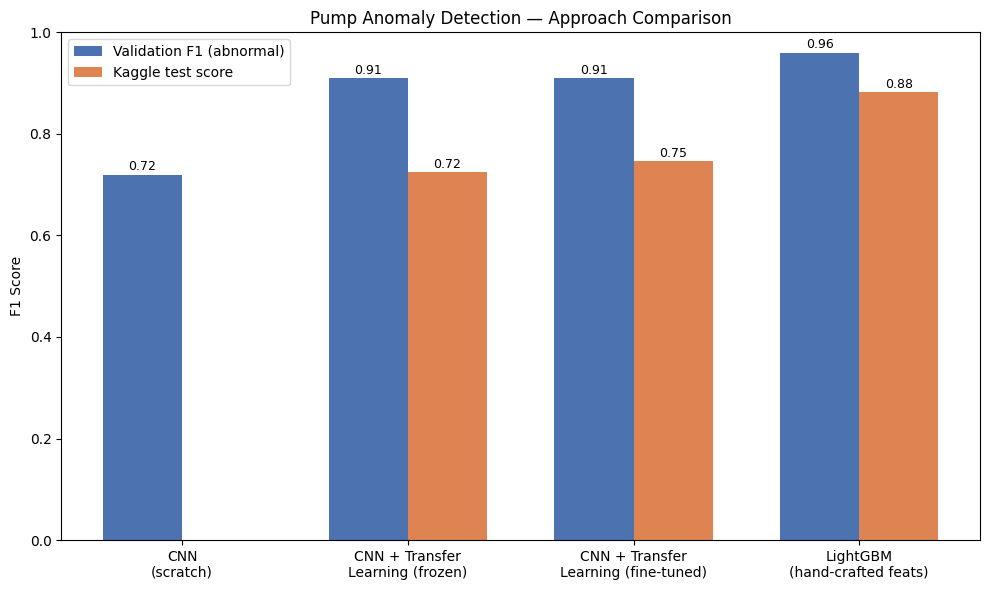

Saved results_comparison.png


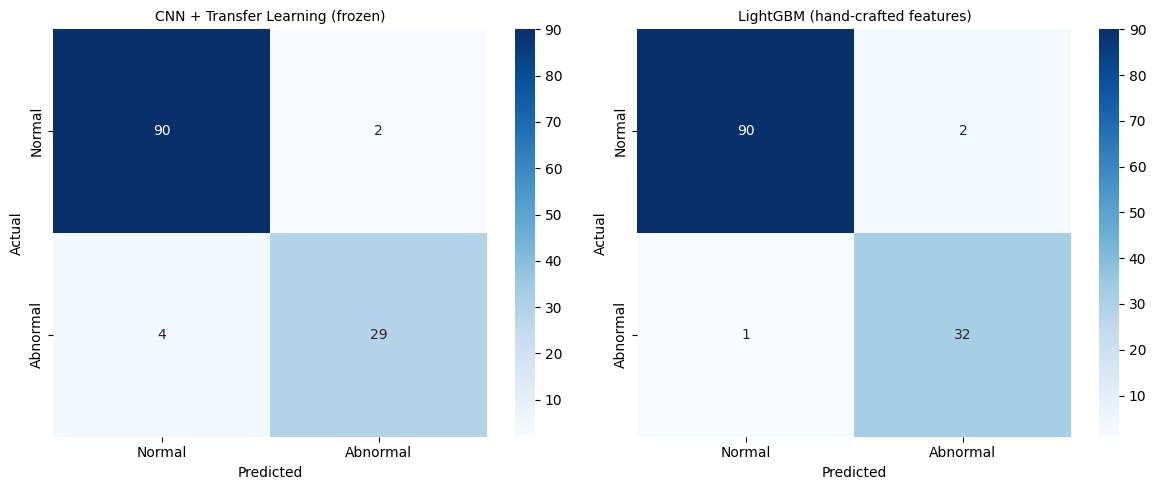

Saved confusion_matrices_comparison.png


In [74]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Comparison bar chart: Abnormal-class F1 across approaches ----
approaches = ["CNN\n(scratch)", "CNN + Transfer\nLearning (frozen)", "CNN + Transfer\nLearning (fine-tuned)", "LightGBM\n(hand-crafted feats)"]
val_f1 = [0.72, 0.91, 0.91, 0.96]
kaggle_scores = [None, 0.72500, 0.74698, 0.88311]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(approaches))
width = 0.35

bars1 = ax.bar(x - width/2, val_f1, width, label="Validation F1 (abnormal)", color="#4C72B0")
kaggle_plot = [v if v is not None else 0 for v in kaggle_scores]
bars2 = ax.bar(x + width/2, kaggle_plot, width, label="Kaggle test score", color="#DD8452")

ax.set_ylabel("F1 Score")
ax.set_title("Pump Anomaly Detection — Approach Comparison")
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.legend()
ax.set_ylim(0, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/results_comparison.png", dpi=150)
plt.show()
print("Saved results_comparison.png")
import seaborn as sns

confusion_matrices = {
    "CNN + Transfer Learning (frozen)": np.array([[90, 2], [4, 29]]),
    "LightGBM (hand-crafted features)": np.array([[90, 2], [1, 32]]),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("/content/confusion_matrices_comparison.png", dpi=150)
plt.show()
print("Saved confusion_matrices_comparison.png")